### 1.Problem Tanıtımı ve Veri Toplama

Bu projenin amacı, Amazon'da en çok satan kitapların özelliklerinden yararlanarak bir kitabın Fiction veya Non-Fiction kategorisine ait olup olmadığını tahmin eden bir makine öğrenmesi modeli geliştirmektir. Bu amaç doğrultusunda kitapların fiyatı, yorum sayısı, alt türü, listede kalma süresi ve yazar bilgisi gibi özellikler kullanılarak kategori sınıflandırması gerçekleştirilmiştir.

Projede, Kaggle platformunda yer alan Amazon Best Selling Books Dataset veri seti kullanılmıştır. Veri seti CSV formatında olup Python ortamında analiz edilmiştir. Veri setinde kitap adı, yazar, kategori, fiyat, puan (Rating), yorum sayısı, listede kalma süresi ve diğer kitap özellikleri yer almaktadır.

Veri seti yalnızca Amazon'un en çok satan 500 kitabını içerdiği için tüm kitapları temsil etmemektedir. Bu nedenle model sonuçları yalnızca kullanılan veri seti kapsamında değerlendirilmiştir. Projenin başarısı; geliştirilen modellerin Accuracy, Classification Report ve Confusion Matrix gibi performans metrikleri kullanılarak değerlendirilmiştir.

In [58]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score

import shap

In [59]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [60]:
df = pd.read_csv(r"c:\Users\slcn1\Downloads\archive\Amazon_BestSelling_Books_500.csv")
df.head()

,Rank,Title,Author,Category,Sub-Genre,Format,Price (USD),Rating,Reviews,Weeks on List,Publisher,Year Published,ISBN,Amazon BSR,Amazon URL
0,1,The Let Them Theory,Mel Robbins,Non-Fiction,Self-Help,Paperback,14.99,4.7,98000.0,52.0,Hay House,2024.0,978-1-13278-859-4,112.0,View
1,2,The Dinner Party,Freida McFadden,Fiction,Psychological Thriller,Paperback,11.69,4.3,1800.0,12.0,Sourcebooks Landmark,2025.0,978-3-76237-716-0,175.0,View
2,3,Project Hail Mary,Andy Weir,Fiction,Science Fiction,Paperback,12.99,4.8,130000.0,108.0,Ballantine Books,2021.0,978-4-30379-320-5,64.0,View
3,4,The Correspondent: A Novel,Virginia Evans,Fiction,Literary Fiction,Hardcover,19.58,4.6,87363.0,28.0,Random House,2025.0,978-6-20328-665-4,143.0,View
4,5,Atomic Habits,James Clear,Non-Fiction,Self-Help / Productivity,Paperback,16.99,4.8,120000.0,220.0,Avery,2018.0,978-7-93320-954-5,237.0,View


In [61]:
df.tail()

,Rank,Title,Author,Category,Sub-Genre,Format,Price (USD),Rating,Reviews,Weeks on List,Publisher,Year Published,ISBN,Amazon BSR,Amazon URL
495,496,Storm Earth,Carmen Maria Machado,Fiction,Climate Fiction,Board Book,10.59,4.7,2108.0,8.0,Entangled: Red Tower Books,2022.0,978-2-31527-636-7,1152.0,View
496,497,The Nurse Untold,Bonnie Garmus,Fiction,Literary Fiction,Hardcover,24.72,4.7,1901.0,6.0,Gallery Books,2024.0,978-4-47249-940-6,6003.0,View
497,498,The Hate,Daniel Kahneman,Non-Fiction,Gift / Journal,Paperback,13.69,4.5,3187.0,6.0,Algonquin Books,2023.0,978-9-46338-926-9,8752.0,View
498,499,Never Signal,David Eddings,Fiction,YA Romance,Kindle Edition,7.82,4.2,1010.0,4.0,Hoover Ink,2023.0,978-6-72190-463-4,9550.0,View
499,500,The Ice of Stars,Isabel Wilkerson,Non-Fiction,Creativity / Art,Hardcover,19.30,4.4,3045.0,14.0,Convergent Books,2022.0,978-5-65584-318-9,4129.0,View


### 2.Veri Hazırlama ve Temizleme

Bu bölümde veri seti modelleme öncesinde incelenmiş ve veri kalitesi değerlendirilmiştir. Veri yapısı, sütun özellikleri, temel istatistikler ve eksik veri durumu analiz edilerek modelleme aşamasına uygunluğu kontrol edilmiştir.

In [62]:
df.columns

Index(['Rank', 'Title', 'Author', 'Category', 'Sub-Genre', 'Format',
       'Price (USD)', 'Rating', 'Reviews', 'Weeks on List', 'Publisher',
       'Year Published', 'ISBN', 'Amazon BSR', 'Amazon URL'],
      dtype='str')

In [63]:
df.shape

(500, 15)

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            500 non-null    int64  
 1   Title           500 non-null    str    
 2   Author          500 non-null    str    
 3   Category        500 non-null    str    
 4   Sub-Genre       500 non-null    str    
 5   Format          500 non-null    str    
 6   Price (USD)     500 non-null    float64
 7   Rating          500 non-null    float64
 8   Reviews         500 non-null    float64
 9   Weeks on List   500 non-null    float64
 10  Publisher       500 non-null    str    
 11  Year Published  500 non-null    float64
 12  ISBN            500 non-null    str    
 13  Amazon BSR      500 non-null    float64
 14  Amazon URL      500 non-null    str    
dtypes: float64(6), int64(1), str(8)
memory usage: 58.7 KB


In [65]:
df.describe()

,Rank,Price (USD),Rating,Reviews,Weeks on List,Year Published,Amazon BSR
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,16.828040,4.412200,12605.154000,25.106000,2021.032000,3862.358000
std,144.481833,6.801869,0.255032,24759.378719,68.100294,5.116183,2368.629814
min,1.000000,4.230000,3.600000,85.000000,1.000000,1965.000000,30.000000
25%,125.750000,11.207500,4.200000,1952.750000,6.000000,2019.000000,1789.750000
50%,250.500000,15.945000,4.400000,3893.000000,12.000000,2022.000000,3735.000000
75%,375.250000,21.930000,4.600000,10986.500000,22.000000,2024.000000,5555.250000
max,500.000000,34.090000,5.000000,220000.000000,1200.000000,2026.000000,9600.000000


In [66]:
df.isnull().sum()

Rank              0
Title             0
Author            0
Category          0
Sub-Genre         0
Format            0
Price (USD)       0
Rating            0
Reviews           0
Weeks on List     0
Publisher         0
Year Published    0
ISBN              0
Amazon BSR        0
Amazon URL        0
dtype: int64

Veri setinde 500 gözlemin tamamında eksik değer bulunmadığı görülmüştür.

### 3.Keşifsel Veri Analizi (EDA) ve Özellik Mühendisliği 

Bu aşamada veri setinin yapısını daha iyi anlamak, değişkenler arasındaki ilişkileri incelemek ve modelleme sürecinde kullanılabilecek anlamlı özellikleri belirlemek amacıyla keşifsel veri analizi yapılmıştır. Kategori dağılımları ve alt tür bilgileri incelenerek veri setindeki genel eğilimler analiz edilmiştir.

Ayrıca model performansını artırmak amacıyla mevcut değişkenlerden yeni özellikler türetilmiştir. Kitap fiyatlarının kategorik olarak değerlendirilmesi için Price_Group, yazarların veri setindeki kitap sayılarını göstermek için ise Author_Book_Count değişkenleri oluşturulmuştur.

EDA sonucunda elde edilen bulguların modelleme aşamasındaki özellik seçimlerine katkı sağlaması amaçlanmıştır.

#### 3.1 Kitapların Kategori Dağılımı

In [67]:
df["Category"].value_counts()

Category
Fiction        254
Non-Fiction    246
Name: count, dtype: int64

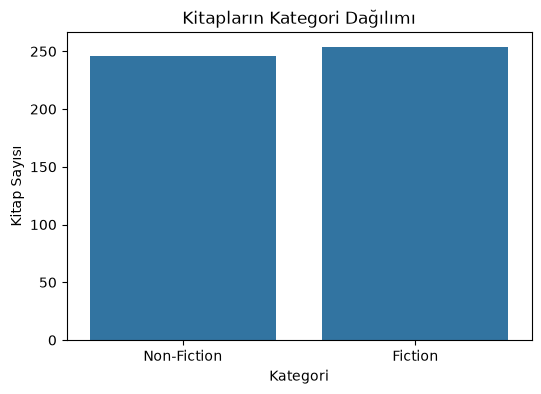

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Category")

plt.title("Kitapların Kategori Dağılımı")
plt.xlabel("Kategori")
plt.ylabel("Kitap Sayısı")

plt.show()

Veri setindeki Fiction ve Non-Fiction kategorilerinin dağılımı incelenmiştir. Sınıfların birbirine yakın sayıda olması, model eğitiminde sınıf dengesizliği probleminin oluşmasını engellemiştir.

#### 3.2 En Çok Bulunan 10 Alt Tür

In [69]:
df["Sub-Genre"].value_counts()

Sub-Genre
Science Fiction               21
Self-Help                     18
Romantasy                     18
Middle Grade                  18
Historical Fiction            17
Psychological Thriller        16
Personal Finance              15
Parenting                     15
Activity / Coloring           14
Memoir                        14
Cooking / Food                14
Spirituality / Religion       14
Politics / Society            14
Biography                     14
Psychology / Health           13
Children's Picture Book       13
Gift / Journal                13
Contemporary Romance          13
Dark Romance                  13
Crime / Detective             13
Climate Fiction               12
Creativity / Art              12
Graphic Novel                 12
YA Dystopian                  11
Space Opera                   11
YA Romance                    11
Literary Fiction              10
Business / Finance            10
Science / Nature              10
Fantasy                       10


In [70]:
df["Sub-Genre"].nunique()

48

Veri setinde toplam 48 farklı alt tür bulunmaktadır.

In [71]:
top10_SubGenre = df["Sub-Genre"].value_counts().head(10)
top10_SubGenre

Sub-Genre
Science Fiction           21
Self-Help                 18
Romantasy                 18
Middle Grade              18
Historical Fiction        17
Psychological Thriller    16
Personal Finance          15
Parenting                 15
Activity / Coloring       14
Memoir                    14
Name: count, dtype: int64

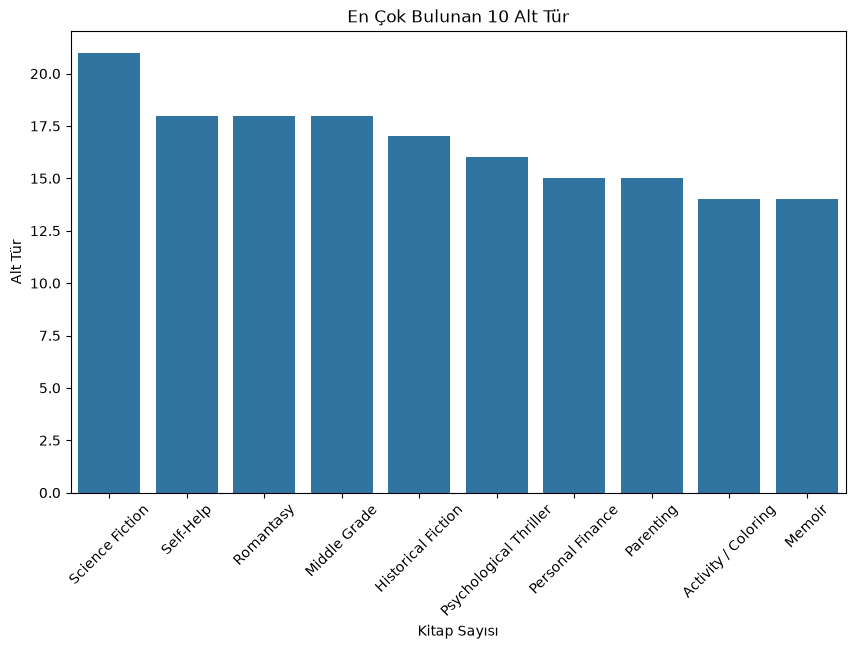

In [72]:
plt.figure(figsize=(10,6))

sns.barplot(x=top10_SubGenre.index, y=top10_SubGenre.values)

plt.title("En Çok Bulunan 10 Alt Tür")
plt.xlabel("Kitap Sayısı")
plt.ylabel("Alt Tür")
plt.xticks(rotation=45)
plt.show()

Alt tür dağılımı incelendiğinde veri setinde bazı alt türlerin diğerlerine göre daha fazla temsil edildiği görülmektedir. En sık karşılaşılan alt türler veri setindeki kitap çeşitliliği hakkında bilgi vermektedir. Alt tür bilgisinin kategori tahmininde önemli bir özellik olabileceği düşünülerek modelleme aşamasında kullanılmıştır.

#### 3.3 Feature Engineering (Özellik Mühendisliği)

Price_Group Oluşturulması

In [73]:
df["Price (USD)"].describe()

count    500.000000
mean      16.828040
std        6.801869
min        4.230000
25%       11.207500
50%       15.945000
75%       21.930000
max       34.090000
Name: Price (USD), dtype: float64

In [74]:
df["Price_Group"] = pd.qcut(
    df["Price (USD)"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [75]:
df["Price_Group"].value_counts()

Price_Group
Low       167
High      167
Medium    166
Name: count, dtype: int64

In [76]:
df[["Price (USD)", "Price_Group"]].head()

,Price (USD),Price_Group
0,14.99,Medium
1,11.69,Low
2,12.99,Medium
3,19.58,High
4,16.99,Medium


Kitap fiyatlarının modele daha anlamlı şekilde aktarılabilmesi amacıyla fiyat değişkeninden yeni bir kategorik değişken oluşturulmuştur. Fiyatlar düşük, orta ve yüksek olmak üzere üç gruba ayrılmıştır.Bu işlem ile sürekli bir değişken olan fiyat bilgisinin kategorik olarak da değerlendirilmesi sağlanmıştır.

Price_Group değişkeni keşifsel analiz amacıyla oluşturulmuş, ancak modelleme aşamasında sürekli fiyat değişkeninin daha fazla bilgi taşıdığı değerlendirilerek orijinal Price (USD) değişkeni kullanılmıştır.

Author_Book_Count Oluşturulması

In [77]:
author_counts = df["Author"].value_counts()
author_counts

Author
Taylor Jenkins Reid    8
Colleen Hoover         8
Matthew Stover         8
Daniel Kahneman        8
Ta-Nehisi Coates       7
                      ..
Kevin J. Anderson      1
Daniel Silva           1
Angela Duckworth       1
Dan Simmons            1
Alastair Reynolds      1
Name: count, Length: 168, dtype: int64

In [78]:
df["Author_Book_Count"] = df["Author"].map(author_counts)

In [79]:
df[["Author", "Author_Book_Count"]].head(10)

,Author,Author_Book_Count
0,Mel Robbins,1
1,Freida McFadden,5
2,Andy Weir,5
3,Virginia Evans,4
4,James Clear,6
5,Sarah J. Maas,3
6,Sarah J. Maas,3
7,Rebecca Yarros,3
8,Bessel van der Kolk,2
9,Jonathan Haidt,6


In [80]:
df["Author_Book_Count"].describe()

count    500.000000
mean       3.936000
std        1.816178
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        8.000000
Name: Author_Book_Count, dtype: float64

Yazar bilgisinden yararlanılarak her yazarın veri setinde kaç kitabının bulunduğunu gösteren yeni bir özellik oluşturulmuştur. Bu değişken, yazarların veri setindeki temsil yoğunluğunu modele aktarmak amacıyla kullanılmıştır.Bu özellik, daha fazla kitabı bulunan yazarların popülerlik veya bilinirlik bilgisini modele yansıtmak amacıyla oluşturulmuştur.

In [81]:
df.head()

,Rank,Title,Author,Category,Sub-Genre,Format,Price (USD),Rating,Reviews,Weeks on List,Publisher,Year Published,ISBN,Amazon BSR,Amazon URL,Price_Group,Author_Book_Count
0,1,The Let Them Theory,Mel Robbins,Non-Fiction,Self-Help,Paperback,14.99,4.7,98000.0,52.0,Hay House,2024.0,978-1-13278-859-4,112.0,View,Medium,1
1,2,The Dinner Party,Freida McFadden,Fiction,Psychological Thriller,Paperback,11.69,4.3,1800.0,12.0,Sourcebooks Landmark,2025.0,978-3-76237-716-0,175.0,View,Low,5
2,3,Project Hail Mary,Andy Weir,Fiction,Science Fiction,Paperback,12.99,4.8,130000.0,108.0,Ballantine Books,2021.0,978-4-30379-320-5,64.0,View,Medium,5
3,4,The Correspondent: A Novel,Virginia Evans,Fiction,Literary Fiction,Hardcover,19.58,4.6,87363.0,28.0,Random House,2025.0,978-6-20328-665-4,143.0,View,High,4
4,5,Atomic Habits,James Clear,Non-Fiction,Self-Help / Productivity,Paperback,16.99,4.8,120000.0,220.0,Avery,2018.0,978-7-93320-954-5,237.0,View,Medium,6


### 4.Modelleme ve Değerlendirme

Bu aşamada, kitapların Fiction ve Non-Fiction kategorilerini tahmin etmek amacıyla farklı makine öğrenmesi modelleri uygulanmıştır. Modellerin performansları Accuracy, Precision, Recall ve F1-Score metrikleri kullanılarak değerlendirilmiş ve çapraz doğrulama yöntemi ile sonuçların güvenilirliği incelenmiştir.Elde edilen sonuçlar karşılaştırılarak en başarılı model belirlenmiştir.

In [82]:
X = df[["Price (USD)", "Reviews", "Weeks on List", "Sub-Genre", "Author_Book_Count"]]
y = df["Category"]

In [83]:
X.head()

,Price (USD),Reviews,Weeks on List,Sub-Genre,Author_Book_Count
0,14.99,98000.0,52.0,Self-Help,1
1,11.69,1800.0,12.0,Psychological Thriller,5
2,12.99,130000.0,108.0,Science Fiction,5
3,19.58,87363.0,28.0,Literary Fiction,4
4,16.99,120000.0,220.0,Self-Help / Productivity,6


In [84]:
y.head()

0    Non-Fiction
1        Fiction
2        Fiction
3        Fiction
4    Non-Fiction
Name: Category, dtype: str

In [85]:
X = pd.get_dummies(
    X,
    columns=["Sub-Genre"],
    drop_first=True
)

In [86]:
X.head()

,Price (USD),Reviews,Weeks on List,Author_Book_Count,Sub-Genre_Art / Activity,Sub-Genre_Biography,Sub-Genre_Business / Finance,Sub-Genre_Business / Leadership,Sub-Genre_Business / Psychology,Sub-Genre_Celebrity Memoir,...,Sub-Genre_Self-Help,Sub-Genre_Self-Help / Memoir,Sub-Genre_Self-Help / Productivity,Sub-Genre_Space Opera,Sub-Genre_Spirituality / Religion,Sub-Genre_True Crime,Sub-Genre_True Crime / History,Sub-Genre_Urban Fantasy,Sub-Genre_YA Dystopian,Sub-Genre_YA Romance
0,14.99,98000.0,52.0,1,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,11.69,1800.0,12.0,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,12.99,130000.0,108.0,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,19.58,87363.0,28.0,4,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,16.99,120000.0,220.0,6,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [87]:
X.shape

(500, 51)

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [89]:
X_train

,Price (USD),Reviews,Weeks on List,Author_Book_Count,Sub-Genre_Art / Activity,Sub-Genre_Biography,Sub-Genre_Business / Finance,Sub-Genre_Business / Leadership,Sub-Genre_Business / Psychology,Sub-Genre_Celebrity Memoir,...,Sub-Genre_Self-Help,Sub-Genre_Self-Help / Memoir,Sub-Genre_Self-Help / Productivity,Sub-Genre_Space Opera,Sub-Genre_Spirituality / Religion,Sub-Genre_True Crime,Sub-Genre_True Crime / History,Sub-Genre_Urban Fantasy,Sub-Genre_YA Dystopian,Sub-Genre_YA Romance
249,5.28,14483.0,5.0,4,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
433,8.53,4776.0,13.0,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19,12.99,14000.0,22.0,1,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
322,9.11,3368.0,14.0,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
332,25.79,2539.0,12.0,3,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,19.84,12450.0,21.0,2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
270,4.87,573.0,14.0,2,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
348,17.00,557.0,15.0,8,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
435,17.28,652.0,8.0,3,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [90]:
y_train

249    Non-Fiction
433        Fiction
19     Non-Fiction
322        Fiction
332        Fiction
          ...     
106        Fiction
270        Fiction
348        Fiction
435    Non-Fiction
102        Fiction
Name: Category, Length: 400, dtype: str

#### 4.1 Logistic Regression Modeli

In [91]:
lr_model = LogisticRegression( max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [92]:
print(y_pred_lr[:10])

['Non-Fiction' 'Non-Fiction' 'Non-Fiction' 'Fiction' 'Non-Fiction'
 'Fiction' 'Fiction' 'Non-Fiction' 'Non-Fiction' 'Fiction']


In [93]:
accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy)

Accuracy: 0.99


In [94]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     Fiction       1.00      0.98      0.99        46
 Non-Fiction       0.98      1.00      0.99        54

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



In [95]:
cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.92 1.   1.   0.99 1.  ]
Mean Accuracy: 0.982


In [96]:
print("Standard Deviation:", cv_scores.std())

Standard Deviation: 0.0312409987036266


Logistic Regression – Veri Bölünmesine Duyarlılık

Cross-Validation standart sapması 0.0312 olarak bulunmuştur. Standart sapmanın düşük olması, modelin farklı veri bölünmelerine karşı duyarlı olmadığını ve fold'lar arasında tutarlı olduğunu göstermektedir.

Logistic Regression – Overfitting Değerlendirmesi

Test accuracy (%99) ile Cross-Validation accuracy (%98.2) değerleri birbirine oldukça yakındır. Bu durum, modelin farklı veri bölünmelerinde de yüksek performans gösterdiğini ve belirgin bir overfitting problemi olmadığını göstermektedir.

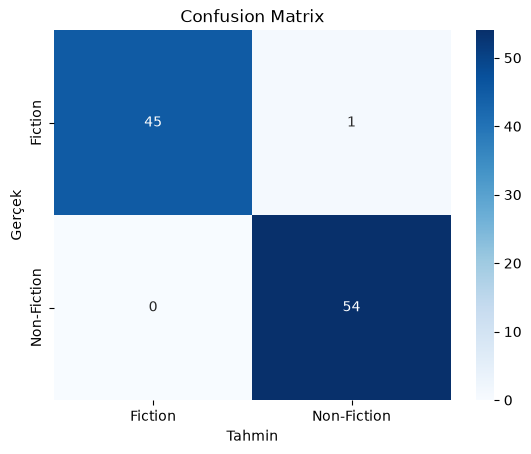

In [97]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()

Logistic Regression modeli test veri setinde %99 doğruluk (Accuracy) elde etmiştir. Classification Report sonuçlarına göre Precision, Recall ve F1-Score değerlerinin her iki sınıf için de oldukça yüksek olduğu görülmektedir. Confusion Matrix incelendiğinde Fiction sınıfındaki 46 kitabın 45'i doğru tahmin edilirken yalnızca 1 kitap yanlış sınıflandırılmıştır. Non-Fiction sınıfındaki 54 kitabın tamamı doğru tahmin edilmiştir. Ayrıca 5 katlı çapraz doğrulama sonucunda ortalama doğruluk değeri %98,2 olarak hesaplanmıştır. Bu sonuçlar modelin yalnızca test verisinde değil, farklı veri bölünmelerinde de tutarlı performans gösterdiğini ortaya koymaktadır.

#### 4.2 Random Forest Modeli

In [98]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

In [99]:
print(y_pred_rf[:10])

['Non-Fiction' 'Non-Fiction' 'Non-Fiction' 'Fiction' 'Non-Fiction'
 'Fiction' 'Fiction' 'Non-Fiction' 'Non-Fiction' 'Fiction']


In [100]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.98
              precision    recall  f1-score   support

     Fiction       0.96      1.00      0.98        46
 Non-Fiction       1.00      0.96      0.98        54

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [101]:
cv_scores_rf = cross_val_score(
    rf_clf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Random Forest Cross Validation Scores:", cv_scores_rf)
print("Random Forest Mean Accuracy:", cv_scores_rf.mean())

Random Forest Cross Validation Scores: [0.9  0.97 1.   0.99 0.99]
Random Forest Mean Accuracy: 0.9700000000000001


In [102]:
print("Standard Deviation:", cv_scores_rf.std())

Standard Deviation: 0.03633180424916989


Random Forest – Veri Bölünmesine Duyarlılık

Cross-Validation standart sapması 0.0363 olarak bulunmuştur. Standart sapmanın düşük olması, modelin farklı veri bölünmelerine karşı duyarlı olmadığını ve fold'lar arasında tutarlı olduğunu göstermektedir.

Random Forest – Overfitting Değerlendirmesi

Test accuracy (%98) ile Cross-Validation accuracy (%97.0) değerleri birbirine oldukça yakındır. Skorlar arasındaki bu küçük fark, modelin farklı veri bölünmelerinde tutarlı bir performans gösterdiğini ve belirgin bir overfitting problemi olmadığını göstermektedir.

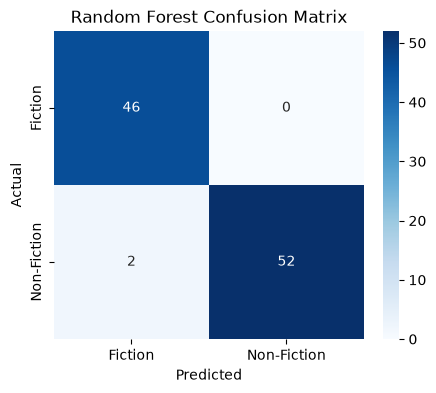

In [103]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fiction", "Non-Fiction"],
    yticklabels=["Fiction", "Non-Fiction"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Random Forest modeli test veri setinde %98 doğruluk (Accuracy) elde etmiştir. Classification Report sonuçlarına göre Precision, Recall ve F1-Score değerlerinin yüksek olduğu görülmektedir. Confusion Matrix incelendiğinde Fiction sınıfındaki 46 kitabın tamamı doğru sınıflandırılmış, Non-Fiction sınıfındaki 54 kitaptan 52'si doğru tahmin edilirken 2 kitap yanlış sınıflandırılmıştır. Ayrıca 5 katlı çapraz doğrulama sonucunda ortalama doğruluk değeri %97 olarak elde edilmiştir. Bu sonuçlar Random Forest modelinin başarılı performans gösterdiğini ancak Logistic Regression modelinin biraz daha yüksek doğruluk sağladığını göstermektedir.

#### 4.3 Model Karşılaştırması

Logistic Regression ve Random Forest modelleri aynı veri seti üzerinde karşılaştırılmıştır. Logistic Regression modeli test veri setinde %99 doğruluk (Accuracy) ve %98,2 ortalama çapraz doğrulama başarısı elde ederken, Random Forest modeli %98 doğruluk ve %97 ortalama çapraz doğrulama başarısı göstermiştir. Her iki model de başarılı sonuçlar üretmesine rağmen Logistic Regression modeli hem test verisi hem de çapraz doğrulama sonuçlarında daha yüksek performans göstermiştir. Bu nedenle proje kapsamında final model olarak Logistic Regression modeli seçilmiştir.

### 5.Model Yorumlanabilirliği ve Sonuçlar 

Model yorumlanabilirliğini artırmak amacıyla Random Forest modeli için Feature Importance analizi, Logistic Regression modeli için ise SHAP analizi uygulanmıştır.

#### 5.1 Feature Importance

In [104]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_clf.feature_importances_
})

In [105]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Price (USD),0.071751
1,Reviews,0.062474
3,Author_Book_Count,0.055489
2,Weeks on List,0.047591
40,Sub-Genre_Science Fiction,0.033048
29,Sub-Genre_Middle Grade,0.032391
38,Sub-Genre_Romantasy,0.031890
31,Sub-Genre_Parenting,0.029354
35,Sub-Genre_Psychological Thriller,0.028927
14,Sub-Genre_Cooking / Food,0.028642


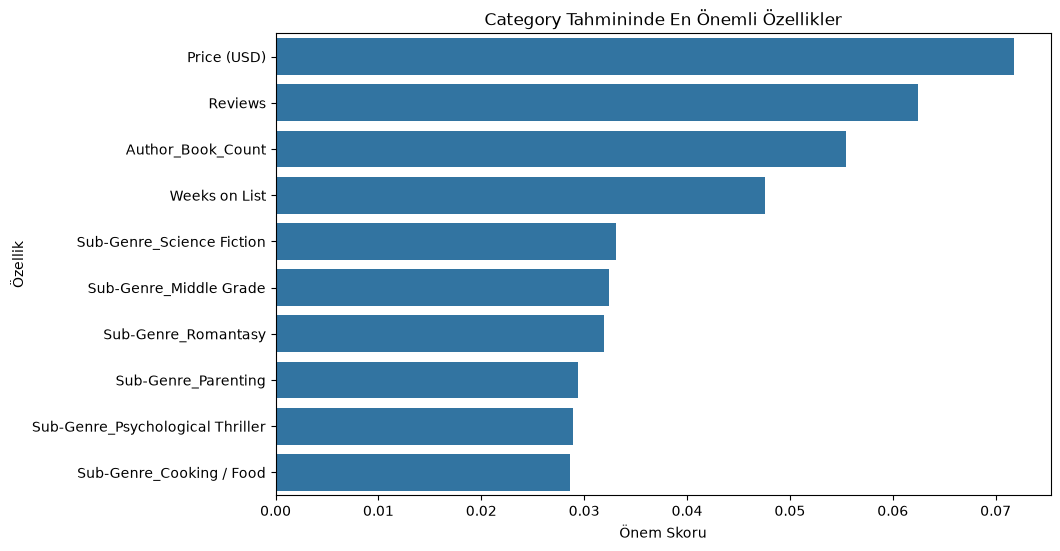

In [106]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Category Tahmininde En Önemli Özellikler")
plt.xlabel("Önem Skoru")
plt.ylabel("Özellik")

plt.show()

Random Forest modelinin karar verme sürecini daha iyi anlayabilmek amacıyla özellik önem skorları (Feature Importance) incelenmiştir. İlk 10 özelliğin önem düzeyi görselleştirilmiştir. Sonuçlara göre Price (USD), Reviews, Author_Book_Count ve Weeks on List değişkenleri modelin kararlarını en fazla etkileyen özellikler olmuştur. Bu bulgular, modelin kitap kategorisini tahmin ederken en çok hangi değişkenlerden yararlandığını göstermektedir.

#### 5.2 Tek Bir Örnek Üzerinde Model Tahmini

In [107]:
sample_index = 0
sample = X_test.iloc[[sample_index]]
sample

,Price (USD),Reviews,Weeks on List,Author_Book_Count,Sub-Genre_Art / Activity,Sub-Genre_Biography,Sub-Genre_Business / Finance,Sub-Genre_Business / Leadership,Sub-Genre_Business / Psychology,Sub-Genre_Celebrity Memoir,...,Sub-Genre_Self-Help,Sub-Genre_Self-Help / Memoir,Sub-Genre_Self-Help / Productivity,Sub-Genre_Space Opera,Sub-Genre_Spirituality / Religion,Sub-Genre_True Crime,Sub-Genre_True Crime / History,Sub-Genre_Urban Fantasy,Sub-Genre_YA Dystopian,Sub-Genre_YA Romance
361,17.65,2545.0,2.0,8,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [108]:
real_category = y_test.iloc[sample_index]
pred_category = lr_model.predict(sample)[0]

print("Gerçek kategori:", real_category)
print("Tahmin edilen kategori:", pred_category)

Gerçek kategori: Non-Fiction
Tahmin edilen kategori: Non-Fiction


In [109]:
prediction_prob = lr_model.predict_proba(sample)
print(prediction_prob)

[[0.12120095 0.87879905]]


In [110]:
print(lr_model.classes_)

['Fiction' 'Non-Fiction']


#### 5.3 SHAP ile Model Açıklaması

In [111]:
explainer = shap.LinearExplainer(
    lr_model,
    X_train
)

Background dataset has 400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=400 when initializing the masker.


In [112]:
shap_values = explainer.shap_values(sample)
shap_values

array([[0.006870340643380422, 0.030409581870910765,
        -0.047478198011734314, 0.13001535701009165, 0.0,
        -0.03243315609142573, -0.02646800416554798, -0.03408524620482811,
        0.0, -0.014032904888587073, -0.0, 0.04851417710239237,
        0.01365174949102461, -0.0, -0.0521641340906159,
        0.03120261921492697, -0.02207669673672313, 0.031220661355120964,
        0.035363616173345255, -0.0, -0.061631605116888595,
        0.06841831683292111, -0.027024967786260706, 0.020395770268326115,
        -0.024831636048660788, 0.0, 0.015124693291496759,
        0.046379566234843, -0.05026891623719071, 0.14359721514156085,
        -0.0, 1.6659914920813255, -0.05256320383346585,
        -0.015332576879911788, -0.02795397897194362, 0.09941939721741455,
        -0.02829833876219175, 0.0, 0.04145063635136286,
        -0.04399724776324732, 0.1325237690579117, -0.050137906551415645,
        -0.0036404511420486617, 0.0, 0.03342682889925732,
        -0.061377256555613526, -0.0525462483741

In [113]:
shap_df = pd.DataFrame({
    "Feature": sample.columns,
    "SHAP_Value": shap_values[0]
})

shap_df["Abs_SHAP"] = shap_df["SHAP_Value"].abs()

shap_df.sort_values(
    "Abs_SHAP",
    ascending=False
).head(10)

,Feature,SHAP_Value,Abs_SHAP
31,Sub-Genre_Parenting,1.665991,1.665991
29,Sub-Genre_Middle Grade,0.143597,0.143597
40,Sub-Genre_Science Fiction,0.132524,0.132524
3,Author_Book_Count,0.130015,0.130015
35,Sub-Genre_Psychological Thriller,0.099419,0.099419
21,Sub-Genre_Graphic Novel,0.068418,0.068418
50,Sub-Genre_YA Romance,0.067896,0.067896
20,Sub-Genre_Gift / Journal,-0.061632,0.061632
45,Sub-Genre_Spirituality / Religion,-0.061377,0.061377
32,Sub-Genre_Personal Finance,-0.052563,0.052563


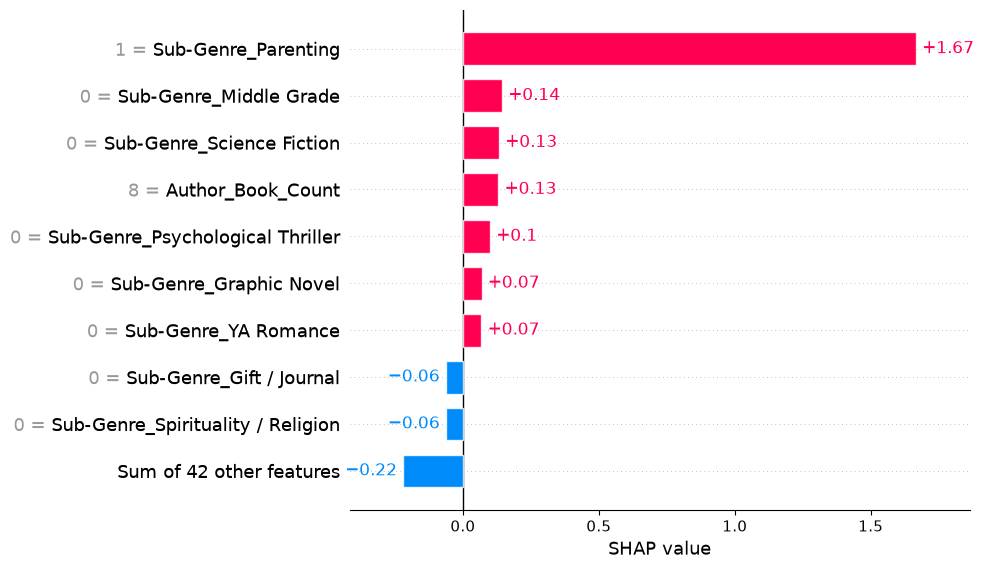

In [114]:
shap.plots.bar(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    ),
max_display=10)

SHAP analizi ile Logistic Regression modelinin tek bir tahmin üzerindeki karar süreci incelenmiştir. Elde edilen sonuçlara göre Sub-Genre_Parenting değişkeni en yüksek SHAP değerine sahip olarak model kararını en fazla etkileyen özellik olmuştur. Bunun yanında Sub-Genre_Middle Grade, Sub-Genre_Science Fiction ve Author_Book_Count değişkenlerinin de tahmin üzerinde önemli etkileri olduğu görülmüştür. Negatif SHAP değerine sahip özelliklerin ise model kararını azaltıcı yönde etkilediği belirlenmiştir. Bu analiz sayesinde modelin yalnızca tahmin sonucu değil, bu tahmine ulaşırken hangi özelliklerden yararlandığı da açıklanmıştır. Ayrıca model, incelenen örnek için kitabın Non-Fiction kategorisinde olma olasılığını yaklaşık %87,9 olarak hesaplamıştır.

#### 5.3 Bulguların İş Diline Çevrilmesi

Geliştirilen model, mevcut veri setindeki kitapların Fiction ve Non-Fiction kategorilerini yüksek doğruluk oranıyla sınıflandırabilmektedir. Analiz sonuçları; kitapların alt türü, fiyatı, yorum sayısı ve yazarın veri setindeki kitap sayısı gibi özelliklerin kategori tahmininde önemli rol oynadığını göstermektedir. Bu tür bir model, çevrim içi kitap satış platformları ve yayınevlerinde kitapların otomatik kategorilendirilmesi, öneri sistemlerinin geliştirilmesi ve kullanıcıların ilgi alanlarına uygun kitaplara daha kolay ulaşması gibi alanlarda kullanılabilir.

### 6. Projenin Kısıtları ve Gelecek Çalışmalar

Bu çalışmada kullanılan veri seti 500 kitaptan oluşmaktadır. Veri setinin sınırlı büyüklükte olması, geliştirilen modellerin daha geniş ve farklı veri kümeleri üzerindeki genellenebilirliğinin değerlendirilmesini zorlaştırmaktadır. Ayrıca çalışmada kitap kategorileri yalnızca Fiction ve Non-Fiction olmak üzere iki sınıf üzerinden incelenmiştir. 

Gelecek çalışmalarda daha büyük ve güncel veri setleri kullanılarak model performansı farklı koşullarda test edilebilir. Hiperparametre optimizasyonu uygulanarak modellerin başarısı artırılabilir. Ayrıca farklı makine öğrenmesi algoritmaları denenerek daha kapsamlı model karşılaştırmaları yapılabilir ve gerçek zamanlı kitap sınıflandırma sistemleri geliştirilebilir.